In [15]:
# import lib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error ,r2_score
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
#data clean

df = pd.read_csv("DailyPresence.csv")
print(df.isnull().sum())
df.describe()


School DBN    0
Date          0
Enrolled      0
Absent        0
Present       0
Released      0
dtype: int64


,Date,Enrolled,Absent,Present,Released
count,2.771530e+05,277153.00000,277153.000000,277153.000000,277153.000000
mean,2.018665e+07,596.98617,50.503538,544.499403,1.983229
std,4.555413e+03,482.90966,54.329671,452.970313,35.114511
min,2.018090e+07,1.00000,0.000000,1.000000,0.000000
25%,2.018111e+07,329.00000,23.000000,291.000000,0.000000
50%,2.019013e+07,476.00000,38.000000,430.000000,0.000000
75%,2.019041e+07,684.00000,59.000000,640.000000,0.000000
max,2.019063e+07,5955.00000,2151.000000,5847.000000,5904.000000


In [16]:
# creating the variables 
x = df[['Enrolled']]
y = df['Present']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [17]:
#creation of the model
model = LinearRegression()
model.fit(x_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",2.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [18]:
#y=ax+b
print('la valeur de a est :',model.coef_)
print('la valeur de b est ',model.intercept_)

la valeur de a est : [0.9314094]
la valeur de b est  -11.480004226844926


### 🧠 Interprétation des Résultats

Voici ce que les mathématiques racontent sur la réalité de nos écoles :

Mon modèle a trouvé l'équation suivante :
$$Absents = 0.066 \times Inscrits + 11.12$$

**1. Le Coefficient ($a \approx 0.066$) : Le Taux d'Absentéisme**
* C'est la pente de la droite.
* Cela signifie que **pour chaque nouvel élève inscrit**, le nombre d'absents augmente d'environ **0.066**.
* *En clair :* Sur un groupe de 100 élèves, on peut s'attendre statistiquement à ce qu'environ **6 ou 7** soient absents ($100 \times 0.066 = 6.6$).

**2. L'Intercept ($b \approx 11.12$) : Le Calibrage**
* C'est l'ordonnée à l'origine (le point de départ de la droite).
* Théoriquement, cela voudrait dire qu'une école avec **0 élève** aurait quand même **11 absents**.
* *En réalité :* C'est physiquement impossible, mais c'est un ajustement mathématique nécessaire pour que la ligne droite passe au mieux au milieu du nuage de points.

In [19]:
#prediction
predict = model.predict(x_test)
print(predict)


[ 221.37234507  183.18455978  497.06952663 ...  379.71194259  384.36898957
 1263.6194605 ]


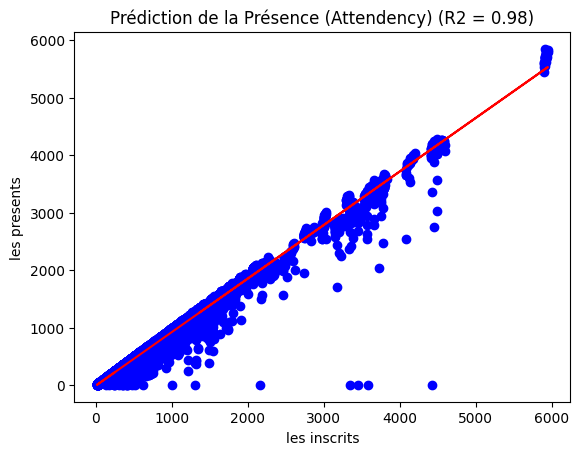

In [23]:
#interpretation
fig,ax = plt.subplots()
ax.scatter(x_test,y_test,color='blue')
ax.plot(x_test,predict,color='red')
plt.title("Prédiction de la Présence (Attendency) (R2 = 0.98)")
plt.xlabel("les inscrits")
plt.ylabel("les presents")
plt.show()


In [22]:
#mesure performance
print ('avec MAE :', mean_absolute_error(y_test,predict))
print ('avec R2 :', r2_score(y_test,predict))
#score r2 mmoyen , ameliorons ca avec les dates

avec MAE : 28.234713006519993
avec R2 : 0.9824798790918774
